# Importing Libraries and functions

In [1]:
import pandas as pd
import numpy as np

# To save and load our models
import pickle

# To plot 
import matplotlib.pyplot as plt
import seaborn  as sns

# To training the model
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble        import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap
from sklearn.inspection import permutation_importance

# Fairlearn 
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
from fairlearn.metrics import equalized_odds_difference,  equalized_odds_ratio
from fairlearn.metrics import selection_rate, true_negative_rate, true_positive_rate, false_positive_rate, false_negative_rate
from fairlearn.metrics import MetricFrame

# Personalized functions
from functions import compute_metrics, fpr, fnr, tmo

# Importing the data

In [2]:
df_trainval = pd.read_csv('CSV_TRAIN.csv', sep = ";")
df_test     = pd.read_csv('CSV_TEST.csv',  sep = ";")

df_trainval['TARGET'] = 1 - df_trainval["DEFAULT"]
df_test['TARGET']     = 1 - df_test["DEFAULT"]

In [3]:
df_trainval_nonulls = df_trainval.dropna().reset_index(drop=True)
df_test_nonulls     = df_test.dropna().reset_index(drop=True)

In [4]:
print(f"After dropping {df_trainval.shape[0] - df_trainval_nonulls.shape[0]} instances with some nulls, the training set has {df_trainval_nonulls.shape[0]} observations")
print(f"After dropping {df_test.shape[0]     - df_test_nonulls.shape[0]} instances with some nulls, the test set has {df_test_nonulls.shape[0]} observations")

After dropping 25 instances with some nulls, the training set has 20029 observations
After dropping 10 instances with some nulls, the test set has 5726 observations


# Train test split

In [5]:
X_trainval   = df_trainval_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_trainval   = df_trainval_nonulls['TARGET']

X_train, X_val, Y_train, Y_val = train_test_split(X_trainval, Y_trainval, test_size = 0.25, random_state = 1)

X_test   = df_test_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_test   = df_test_nonulls['TARGET']


PF1_train = X_train['PF1']
PF2_train = X_train['PF2']

PF1_val   = X_val['PF1']
PF2_val   = X_val['PF2']

PF1_test  = X_test['PF1']
PF2_test = X_test['PF2']

X_train = X_train.drop(['PF1'], axis = 1)
X_val   = X_val.drop(['PF1'], axis = 1)
X_test  = X_test.drop(['PF1'], axis = 1)

In [6]:
print(f" The dataset we will use for training   has {X_train.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for validation has {X_val.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for test       has {X_test.shape[0]} observations and {X_test.shape[1]} features.")

 The dataset we will use for training   has 15021 observations and 17 features.
 The dataset we will use for validation has 5008 observations and 17 features.
 The dataset we will use for test       has 5726 observations and 17 features.


# In the search of the optimal delta

In this notebook we will be applying the same reweighing technique but this time the model will be able to use the protected feature.

In [7]:
param_grid = {
    'max_depth': [2, 4],
    'learning_rate': [0.01, 0.025, 0.05],
    'n_estimators': [1000],
    'gamma': [10, 25],
    'subsample': [0.8],
    'colsample_bytree': [0.75],
    'min_child_weight': [8, 32],
    'early_stopping_rounds': [50]}
   

As we will have to optimize the hyperparameters for 20 deltas, we have reduced a bit the space of hyperparameters leveraging some of the insights we got from the optimization of hyperparameters in the base model and the unaware model. 

In [8]:
metrics = {
    "Default_rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}


In [9]:
deltas = np.linspace(0.75, 2.5, 20)
thresholds = np.linspace(0.7, 1, 250)

columns_summary = ["Delta", "Threshold", "Default_Rate", "Accuracy", 
                    "Precision", "Recall", "Selection_Rate",
                 "FPR", "FNR", "Specificity"]

rows_summary = []
best_params_by_delta = {}

for delta in deltas:
    
    
    # Example: manually boost group with lower recall
    weights = np.ones(len(Y_train))

    # As group 1 in the protected feature 2 have lower recall, we will increase the weight of positive sample of this group
    weights[(PF2_train == 1) & (Y_train == 1)] *= delta

    xgb_aw_reweighted = XGBClassifier(random_state=1)
    
    print(f"Looking for the best hyperparameters of the model with delta: {delta}")
    # For each delta we perform a GridSearch to find the optimal hyperparameters.
    grid_search = GridSearchCV(estimator=xgb_aw_reweighted, param_grid=param_grid, cv=4, scoring='roc_auc', n_jobs=2, verbose=1, return_train_score=True)

    # Calling grid_search on our data
    grid_search.fit(X_train, Y_train, sample_weight = weights)

    # Save the results
    cv_results = grid_search.cv_results_
    
    # We create a df with the AUC obtained in train and test for different hyperparameters. 
    results_df = pd.DataFrame({'params': cv_results['params'],
                           'mean_train_gini': 2*cv_results['mean_train_score']-1,
                           'mean_test_gini': 2*cv_results['mean_test_score']-1,
                           'gini_diff': (2*cv_results['mean_train_score'] -1) - (2*cv_results['mean_test_score']-1)})
    results_df_filter = results_df.sort_values('mean_test_gini', ascending=False)
    results_df_filter = results_df_filter[results_df_filter['gini_diff']<0.03]
    
    # If we could not find any hyperparameters satisfying our overfitting criteria, we go on to the next delta
    if results_df_filter.empty:
        continue

    best_hyperparams = results_df_filter.sort_values('mean_test_gini', ascending=False).iloc[0, 0]
    # We add the hyperparameters to a dictionary so we can retrieve them later to train the final model
    #Which will be the model obtained with the delta that better suits our goal of improving fairness 
    # while minimizing profitability loss
    
    best_params_by_delta[delta] = best_hyperparams
    
    xgb_aw_reweighted = XGBClassifier(**best_hyperparams, random_state=1, n_jobs=2)
    xgb_aw_reweighted.fit(X_train, Y_train, sample_weight = weights)
    
    rows_threshold = []
    for t in thresholds:
        resultado = compute_metrics(X_val, Y_val, xgb_aw_reweighted, t)
        rows_threshold.append(resultado)

    df_metricas = pd.DataFrame(rows_threshold, 
                                columns=['Threshold', 'TMO', 'TasaAprovados', 
                                            'Recall', 'Precision', 'FPR', 'FNR'])
  
    df_metricas_filtered = df_metricas.sort_values('TasaAprovados', ascending=False)
    df_metricas_filtered = df_metricas_filtered[df_metricas_filtered['TMO'] < 0.05]

    # If we could not find any threshold satisfying our default rate criteria, we go on to the next delta
    if df_metricas_filtered.empty:
        continue
    best_threshold = df_metricas_filtered.iloc[0,0]
    
    print("Best threshold found. Evaluating now fairness metrics.")
    
    prob_val = xgb_aw_reweighted.predict_proba(X_val)[:, 1]
    
    mf = MetricFrame(
        metrics=metrics,
        y_true= Y_val,
        y_pred=( prob_val > best_threshold),
        sensitive_features= PF2_val
    )
    ratios = [ delta, best_threshold, mf.ratio()["Default_rate"], mf.ratio()["Accuracy"], 
                  mf.ratio()["Precision"], mf.ratio()["Recall"], mf.ratio()["Selection_rate"],
                 mf.ratio()["FPR"], mf.ratio()["FNR"], mf.ratio()["Specificity"] ]
    rows_summary.append(ratios)

summary = pd.DataFrame(rows_summary, columns= columns_summary)
print("Summary done!")


Looking for the best hyperparameters of the model with delta: 0.75
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 0.8421052631578947
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 0.9342105263157895
Fitting 4 folds for each of 24 candidates, totalling 96 fits


...

Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 2.4078947368421053
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 2.5
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Summary done!


In [10]:
summary

,Delta,Threshold,Default_Rate,Accuracy,Precision,Recall,Selection_Rate,FPR,FNR,Specificity
0,0.750000,0.890361,0.894999,0.736871,0.994369,0.652717,0.622991,0.399040,0.594468,0.752436
1,0.842105,0.891566,0.936974,0.800472,0.996701,0.730779,0.699135,0.468813,0.657033,0.782921
2,0.934211,0.896386,0.976762,0.822231,0.998793,0.758716,0.727385,0.508469,0.681984,0.798416
3,1.026316,0.897590,0.955200,0.824103,0.997629,0.761976,0.729660,0.498800,0.670598,0.784683
4,1.118421,0.900000,0.981209,0.847030,0.999013,0.789791,0.757345,0.531822,0.704702,0.801080
5,1.210526,0.902410,0.967370,0.843165,0.998246,0.787628,0.757345,0.560289,0.702224,0.813326
6,1.302632,0.906024,0.976882,0.851272,0.998786,0.796327,0.765295,0.560658,0.715573,0.818291
7,1.394737,0.907229,0.891572,0.879437,0.993994,0.834534,0.805880,0.646883,0.759185,0.856775
8,1.486842,0.908434,0.893425,0.911933,0.994026,0.873815,0.843785,0.675904,0.806483,0.865065
9,1.578947,0.908434,0.923921,0.966253,0.995851,0.937633,0.903751,0.700044,0.895645,0.873848


In [11]:
best_delta = 1.763157894736842
best_threshold = 0.918072

weights = np.ones(len(Y_train))

weights[(PF2_train == 1) & (Y_train == 1)] *= best_delta


xgb_aw_reweighted = XGBClassifier( **best_params_by_delta[best_delta], random_state = 1)

print(f"Training model with delta {best_delta}.")
xgb_aw_reweighted.fit(X_train, Y_train, sample_weight=weights)
print(f"Training Done!")


Training model with delta 1.763157894736842.
Training Done!


# Saving the model

In [12]:
# We save the hyperparameters for the model in a csv
xgb_reweighted_hparams = pd.DataFrame([best_params_by_delta[best_delta]])
xgb_reweighted_hparams.to_csv("xgb_aware_reweighted_hparams.csv", index=False)

pickle.dump(xgb_aw_reweighted, open('xgb_aw_reweighted.cls', 'wb'))

# Evaluating model performance

In [13]:
xgb_aw_reweighted = pickle.load(open('./xgb_aw_reweighted.cls', "rb"))

In [14]:
prob_train = xgb_aw_reweighted.predict_proba(X_train)[:, 1]
prob_val   = xgb_aw_reweighted.predict_proba(X_val)[:, 1]
prob_test  = xgb_aw_reweighted.predict_proba(X_test)[:, 1]

auc_score_train  = roc_auc_score(Y_train, prob_train)
gini_score_train = 2*auc_score_train-1

auc_score_val = roc_auc_score(Y_val, prob_val)
gini_score_val = 2*auc_score_val-1

auc_score_test  = roc_auc_score(Y_test, prob_test)
gini_score_test = 2*auc_score_test-1

print(f"El ROC-AUC del modelo en train es {auc_score_train:.4f}")
print(f"El GINI del modelo  en train es {gini_score_train:.4f}")

print(f"El ROC-AUC del modelo en validación es {auc_score_val:.4f}")
print(f"El GINI del modelo  en validación es {gini_score_val:.4f}")

print(f"El ROC-AUC del modelo en test es {auc_score_test:.4f}")
print(f"El GINI del modelo  en test es {gini_score_test:.4f}")

El ROC-AUC del modelo en train es 0.7525
El GINI del modelo  en train es 0.5051
El ROC-AUC del modelo en validación es 0.7390
El GINI del modelo  en validación es 0.4781
El ROC-AUC del modelo en test es 0.7255
El GINI del modelo  en test es 0.4510


# Explainability

In [15]:
importancias = xgb_aw_reweighted.feature_importances_
df_importancia = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias}).sort_values(by = 'Importancia', ascending = False)

In [16]:
print(df_importancia)

     Variable  Importancia
1    BEH_VAR1     0.134458
3    FIN_VAR1     0.084999
14   BEH_VAR6     0.083790
8    FIN_VAR2     0.080708
13   BEH_VAR5     0.078709
10        PF2     0.077034
7   LOAN_VAR3     0.074874
5    BEH_VAR2     0.068620
4    BEH_VAR3     0.067482
9    FIN_VAR3     0.065798
6   LOAN_VAR2     0.064867
0   LOAN_VAR1     0.064139
12   BEH_VAR4     0.054520
11    SE_VAR2     0.000000
2    FIN_VAR4     0.000000
15    SE_VAR1     0.000000
16    SE_VAR3     0.000000


In [17]:
feature_permutation_importance = permutation_importance(xgb_aw_reweighted, X_train, Y_train, scoring='roc_auc', n_repeats=5, random_state = 1)

In [18]:
importances = feature_permutation_importance.importances_mean
feature_importance = pd.Series(importances, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance)

BEH_VAR1     0.068564
LOAN_VAR3    0.043972
BEH_VAR6     0.022597
FIN_VAR1     0.018252
FIN_VAR2     0.014126
FIN_VAR3     0.006844
BEH_VAR5     0.003321
PF2          0.002802
LOAN_VAR1    0.002771
BEH_VAR2     0.001396
BEH_VAR3     0.001378
LOAN_VAR2    0.001193
BEH_VAR4     0.000361
SE_VAR1      0.000000
SE_VAR2      0.000000
FIN_VAR4     0.000000
SE_VAR3      0.000000
dtype: float64


In [19]:
explainer = shap.TreeExplainer(xgb_aw_reweighted)
shap_values = explainer.shap_values(X_val)


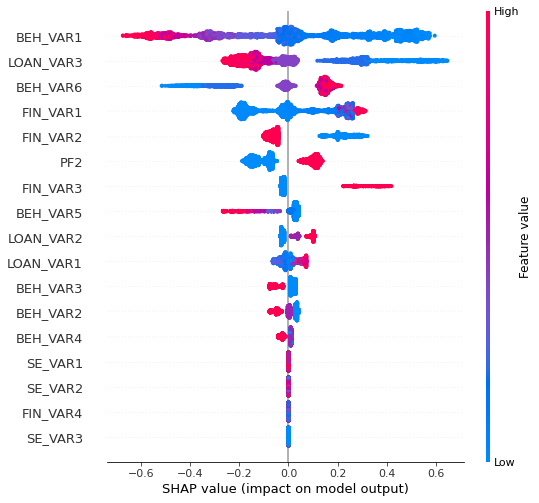

In [20]:
shap.summary_plot(shap_values, X_val)

# Performance on test set

In [21]:
rows_test = []
resultado = compute_metrics(X_test, Y_test, xgb_aw_reweighted, best_threshold)
rows_test.append(resultado)

df_metricas_test = pd.DataFrame(rows_test, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])
df_metricas_test.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
0,0.918072,0.051823,0.579637,0.616454,0.948177,0.276973,0.383546


# Fairness Metrics

In [22]:
metrics = {
    "N": lambda y_true, y_pred: len(y_true),
    "Default_rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}

mf1 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF1_test
)

mf2 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF2_test
)

# Check the combination of features, this is called intersectional fairness, 
# it could happen that at group level the model is fair
# but when considering the combination of protected features we might detect bias
intersectional_fairness = pd.DataFrame({"PF1": PF1_test, "PF2": PF2_test})

mf12 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= intersectional_fairness
)

Fairness Metrics grouping by Protected Feature 1

In [23]:
mf1.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF1,,,,,,,,,
0,2522,0.0448808,0.612213,0.955119,0.598418,0.565424,0.260163,0.401582,0.739837
1,3204,0.0570523,0.640449,0.942948,0.630965,0.590824,0.288,0.369035,0.712


In [24]:
mf1.ratio()

N                 0.787141
Default_rate       0.78666
Accuracy          0.955911
Precision         0.987257
Recall            0.948418
Selection_rate     0.95701
FPR               0.903342
FNR               0.918954
Specificity       0.962374
dtype: object

Fairness Metrics grouping by Protected Feature 2

In [25]:
mf2.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF2,,,,,,,,,
0,3484,0.0493164,0.627727,0.950684,0.619472,0.58783,0.296188,0.380528,0.703812
1,2242,0.0558615,0.628457,0.944138,0.611621,0.566905,0.253571,0.388379,0.746429


In [26]:
mf2.ratio()

N                 0.643513
Default_rate      0.882833
Accuracy          0.998838
Precision         0.993115
Recall            0.987326
Selection_rate    0.964402
FPR               0.856117
FNR               0.979785
Specificity       0.942906
dtype: object

Fairness Metrics grouping by the intersection of protected features

In [27]:
mf12.by_group.head()

N Default_rate  Accuracy Precision    Recall Selection_rate  \
PF1 PF2                                                                   
0   0    1609    0.0442765   0.61156  0.955724  0.602451       0.575513   
    1     913        0.046  0.613363     0.954  0.591078       0.547645   
1   0    1875    0.0534759    0.6416  0.946524  0.634409         0.5984   
    1    1329    0.0622568  0.638826  0.937743  0.625974       0.580135   

              FPR       FNR Specificity  
PF1 PF2                                  
0   0    0.292857  0.397549    0.707143  
    1    0.216981  0.408922    0.783019  
1   0    0.298507  0.365591    0.701493  
    1    0.275862  0.374026    0.724138

In [28]:
mf12.ratio()

N                 0.486933
Default_rate      0.711191
Accuracy           0.95318
Precision         0.981187
Recall            0.931699
Selection_rate    0.915182
FPR               0.726887
FNR               0.894037
Specificity       0.895882
dtype: object